<a href="https://colab.research.google.com/github/swirita/Chicago-Crime-Analysis-and-Forecasting/blob/main/notebooks/02_crime_analysis_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis & Forecasting

- Author: Siwar Ehwass

## Overview

## Imports

In [27]:
%pip install -q holidays pmdarima

import pandas as pd
import numpy as np
import glob
import os
import holidays

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

In [28]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

## Custom Functions

In [23]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [24]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [25]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [26]:
### NEW FUNCTION FOR COMBINED ACF/PACF WITH ANNOTATIONS
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")
        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m
        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
    fig.tight_layout()

    return fig


In [ ]:

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

## Load & Explore Data

In [2]:
DATA_FOLDER = (
    "/content/drive/MyDrive/"
    "Chicago-Crime-Analysis-and-Forecasting/data/raw"
)

crime_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "Chicago-Crime_*.csv")))

print(f"Number of files found: {len(crime_files)}")
crime_files

Number of files found: 26


['/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2001.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2002.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2003.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2004.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2005.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2006.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2007.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2008.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2009.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2010.csv',
 '/content/drive/MyD

In [3]:
def load_crime_file(file):
    temp_df = pd.read_csv(
        file,
        low_memory=False
    )

    temp_df["Date"] = pd.to_datetime(
        temp_df["Date"],
        format="%m/%d/%Y %I:%M:%S %p",
        errors="coerce"
    )

    return temp_df.dropna(subset=["Date"])

In [4]:
df = pd.concat(
    (load_crime_file(file) for file in crime_files),
    ignore_index=True
)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,5462733,2001-01-01 01:00:00,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849
1,1311933,2001-01-01 01:00:00,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214
2,1312658,2001-01-01 01:00:00,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575
3,1313213,2001-01-01 01:00:00,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698
4,1315458,2001-01-01 01:00:00,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8627693 entries, 0 to 8627692
Data columns (total 12 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Date                  datetime64[ns]
 2   Primary Type          object        
 3   Description           object        
 4   Location Description  object        
 5   Arrest                bool          
 6   Domestic              bool          
 7   Beat                  int64         
 8   District              float64       
 9   Ward                  float64       
 10  Latitude              float64       
 11  Longitude             float64       
dtypes: bool(2), datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 674.7+ MB


## Feature Engineering: US Holidays

In [6]:
## making a date range that covers full dataset
all_days = pd.date_range(df["Date"].min(), df["Date"].max())
all_days

DatetimeIndex(['2001-01-01', '2001-01-02', '2001-01-03', '2001-01-04',
               '2001-01-05', '2001-01-06', '2001-01-07', '2001-01-08',
               '2001-01-09', '2001-01-10',
               ...
               '2026-08-16', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23',
               '2026-08-24', '2026-08-25'],
              dtype='datetime64[ns]', length=9368, freq='D')

In [14]:
## Create an instance of the US country holidays.
us_holidays = holidays.country_holidays('US')
us_holidays

holidays.country_holidays('US')

In [15]:
## Saving holiday types as columns
df["US Holiday"] = [us_holidays.get(day) for day in df['Date']]
df.head(5)

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,US Holiday
0,5462733,2001-01-01 01:00:00,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849,New Year's Day
1,1311933,2001-01-01 01:00:00,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214,New Year's Day
2,1312658,2001-01-01 01:00:00,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575,New Year's Day
3,1313213,2001-01-01 01:00:00,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698,New Year's Day
4,1315458,2001-01-01 01:00:00,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,New Year's Day


In [16]:
## US Holidays
df['US Holiday'].value_counts()

,count
US Holiday,
New Year's Day,37240
Independence Day,25755
Labor Day,24506
Memorial Day,24069
Columbus Day,22935
Veterans Day,22348
Martin Luther King Jr. Day,20077
Washington's Birthday,20072
Thanksgiving Day,16245


/tmp/ipykernel_442/2717788790.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');


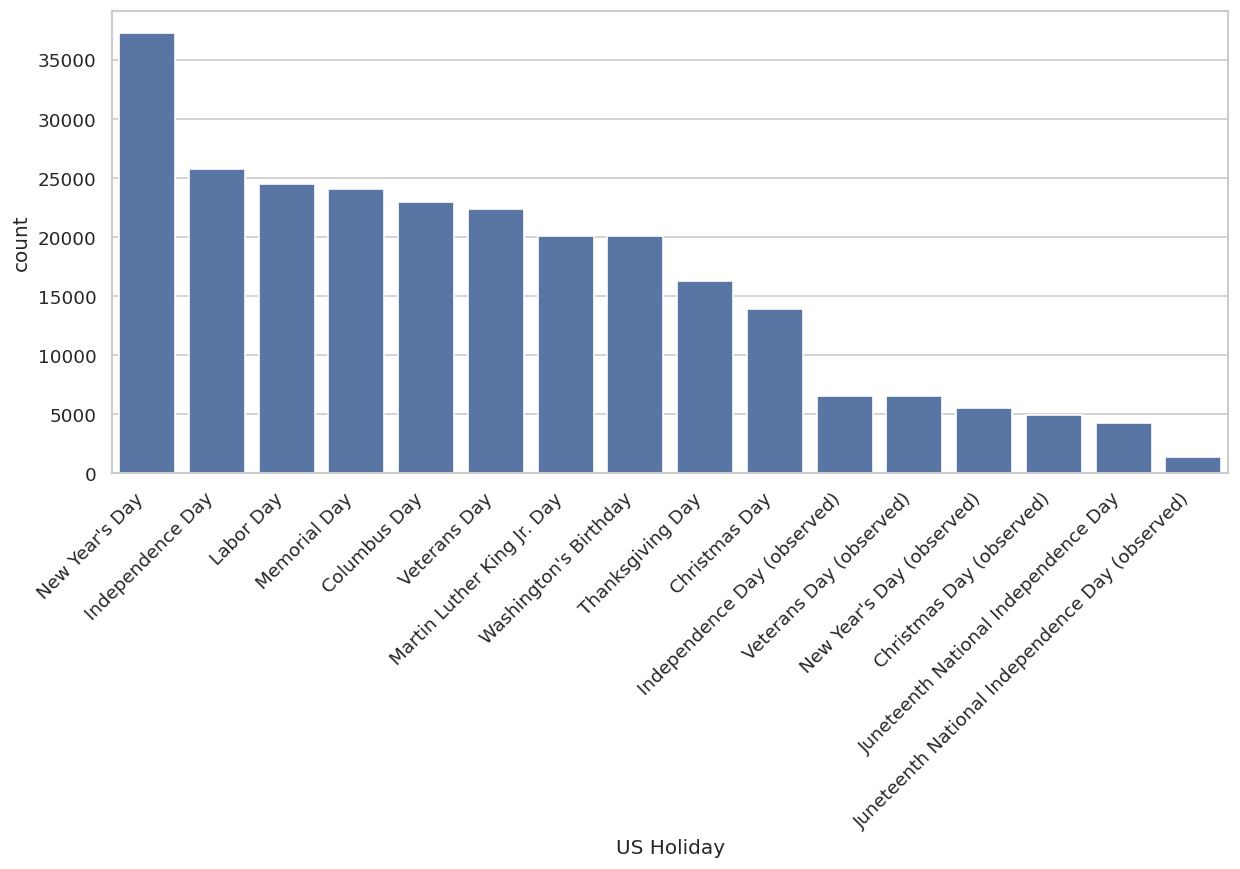

In [17]:
ax= sns.countplot(data=df, x="US Holiday", order=df["US Holiday"].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');

In [18]:
## Saving a binary is holiday feature
df['Is_Holiday'] = df['US Holiday'].notna()
df['Is_Holiday'].value_counts()

,count
Is_Holiday,
False,8371203
True,256490


In [19]:
df = df.set_index("Date")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8627693 entries, 2001-01-01 01:00:00 to 2026-08-25 00:00:00
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
 11  US Holiday            object 
 12  Is_Holiday            bool   
dtypes: bool(3), float64(4), int64(2), object(4)
memory usage: 748.7+ MB


In [20]:
print("Shape:", df.shape)
print("First date:", df.index.min())
print("Last date:", df.index.max())

df.head()

Shape: (8627693, 13)
First date: 2001-01-01 00:00:00
Last date: 2026-08-25 00:00:00


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,US Holiday,Is_Holiday
Date,,,,,,,,,,,,,
2001-01-01 01:00:00,5462733,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849,New Year's Day,True
2001-01-01 01:00:00,1311933,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214,New Year's Day,True
2001-01-01 01:00:00,1312658,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575,New Year's Day,True
2001-01-01 01:00:00,1313213,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698,New Year's Day,True
2001-01-01 01:00:00,1315458,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,New Year's Day,True


In [21]:
df['ID'].duplicated().sum()

np.int64(0)

In [22]:
df['Primary Type'].isna().sum()

np.int64(0)

In [29]:
df.head(5)

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,US Holiday,Is_Holiday
Date,,,,,,,,,,,,,
2001-01-01 01:00:00,5462733,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849,New Year's Day,True
2001-01-01 01:00:00,1311933,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214,New Year's Day,True
2001-01-01 01:00:00,1312658,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575,New Year's Day,True
2001-01-01 01:00:00,1313213,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698,New Year's Day,True
2001-01-01 01:00:00,1315458,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,New Year's Day,True


## Crimes Across the Years

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

In [30]:
annual_counts = df.resample('YS').size()
annual_counts.index = annual_counts.index.year
annual_counts.index.name = 'Year'
annual_counts.name = 'Number of Crimes'

In [31]:
annual_counts.head(3)

,Number of Crimes
Year,
2001,485974
2002,486839
2003,476007


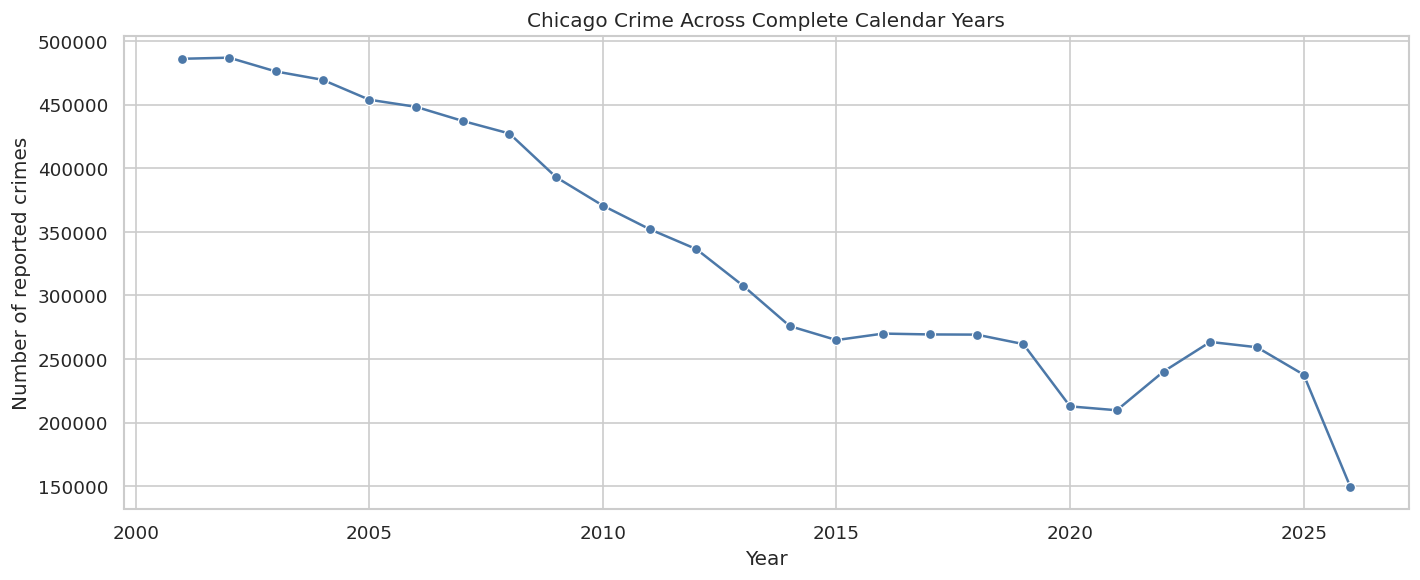

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    x=annual_counts.index,
    y=annual_counts.values,
    marker='o',
    color='#4C78A8',
    ax=ax
)
ax.set(
    title='Chicago Crime Across Complete Calendar Years',
    xlabel='Year',
    ylabel='Number of reported crimes'
)
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()

In [34]:
first_year = annual_counts.index.min()
last_year = annual_counts.index.max()

first_year_total = annual_counts.loc[first_year]
last_year_total = annual_counts.loc[last_year]

overall_trend = 'increasing' if last_year_total > first_year_total else 'decreasing'
print(f"Overall crime trend: {overall_trend}")
print(f"({first_year}: {first_year_total} crimes -> {last_year}: {last_year_total} crimes)")

Overall crime trend: decreasing
(2001: 485974 crimes -> 2026: 149408 crimes)


In [35]:
crime_by_year = df.groupby([df.index.year, 'Primary Type']).size().unstack(fill_value=0)

first_year_counts = crime_by_year.loc[first_year]
last_year_counts = crime_by_year.loc[last_year]

# True if that crime type went up, False if it went down
crime_increased = last_year_counts > first_year_counts

# Opposite = went up while overall went down, or vice versa
if overall_trend == 'increasing':
    opposite_crimes = crime_increased[crime_increased == False]
else:
    opposite_crimes = crime_increased[crime_increased == True]

print(f"{len(opposite_crimes)} crime types move opposite to the overall trend:")
print(opposite_crimes.index.tolist())

8 crime types move opposite to the overall trend:
['CONCEALED CARRY LICENSE VIOLATION', 'CRIMINAL SEXUAL ASSAULT', 'HUMAN TRAFFICKING', 'INTERFERENCE WITH PUBLIC OFFICER', 'NON-CRIMINAL', 'OBSCENITY', 'PUBLIC INDECENCY', 'STALKING']


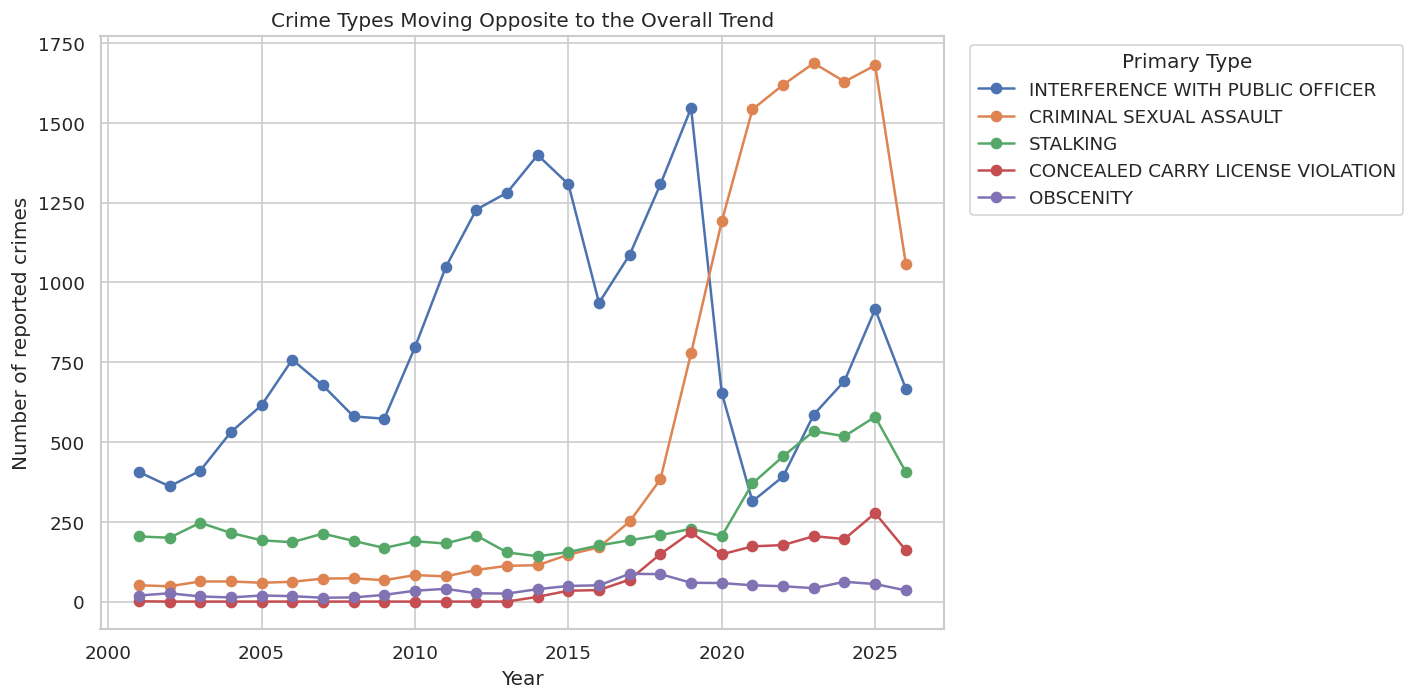

In [37]:
opposite_top = crime_by_year[opposite_crimes.index].sum().sort_values(ascending=False).head(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
crime_by_year[opposite_top].plot(ax=ax, marker='o')
ax.set(
    title='Crime Types Moving Opposite to the Overall Trend',
    xlabel='Year',
    ylabel='Number of reported crimes'
)
ax.legend(title='Primary Type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

## Comparing AM vs. PM Rush Hour:
- Are crimes more common during AM rush hour or PM rush hour?
- consider any crime that occurred between 7 AM - 10 AM as AM rush hour
, any crime that occurred between 4 - 7 PM as PM rush hour.

- What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?

- Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

In [39]:
# Tag each crime as AM or PM rush hour
hour = df.index.hour
am_mask = (hour >= 7) & (hour < 10)
pm_mask = (hour >= 16) & (hour < 19)

rush_df = df.loc[am_mask | pm_mask, ['Primary Type']].copy()
rush_df['Rush Hour'] = np.where(am_mask[am_mask | pm_mask], 'AM Rush Hour', 'PM Rush Hour')

In [40]:
rush_df = df.loc[am_mask | pm_mask, ['Primary Type']].copy()
rush_df['Rush Hour'] = np.where(
    (rush_df.index.hour >= 7) & (rush_df.index.hour < 10),
    'AM Rush Hour',
    'PM Rush Hour'
)

In [41]:
# Which is more common overall?
rush_totals = rush_df['Rush Hour'].value_counts().reindex(['AM Rush Hour', 'PM Rush Hour'])
print(rush_totals)

more_common_rush = rush_totals.idxmax()
print(f"\n{more_common_rush} has more reported crimes.")

Rush Hour
AM Rush Hour     863343
PM Rush Hour    1352388
Name: count, dtype: int64

PM Rush Hour has more reported crimes.


In [44]:
for rush_name in ['AM Rush Hour', 'PM Rush Hour']:
    top5 = (
        rush_df[rush_df['Rush Hour'] == rush_name]['Primary Type']
        .value_counts()
        .head(5)
    )
    print(f"\nTop 5 crimes during {rush_name}:")
    print(top5)


Top 5 crimes during AM Rush Hour:
Primary Type
THEFT              206607
BATTERY            123474
CRIMINAL DAMAGE     91156
BURGLARY            77427
OTHER OFFENSE       69818
Name: count, dtype: int64

Top 5 crimes during PM Rush Hour:
Primary Type
THEFT              331085
BATTERY            237998
CRIMINAL DAMAGE    148549
NARCOTICS          107217
ASSAULT            104249
Name: count, dtype: int64


In [46]:
# Motor Vehicle Theft AM or PM?
mvt = rush_df[rush_df['Primary Type'] == 'MOTOR VEHICLE THEFT']
mvt_counts = mvt['Rush Hour'].value_counts().reindex(['AM Rush Hour', 'PM Rush Hour'])
print(mvt_counts)

more_common_mvt = mvt_counts.idxmax()
print(f"\nMotor Vehicle Theft is more common during {more_common_mvt}.")

Rush Hour
AM Rush Hour    48951
PM Rush Hour    66420
Name: count, dtype: int64

Motor Vehicle Theft is more common during PM Rush Hour.


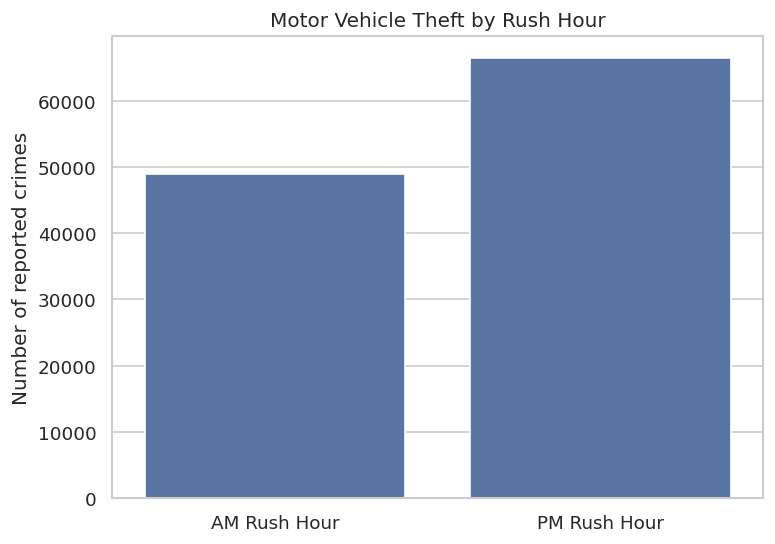

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=mvt_counts.index, y=mvt_counts.values, ax=ax)
ax.set(title='Motor Vehicle Theft by Rush Hour', xlabel='', ylabel='Number of reported crimes')
plt.show()

## Comparing Holidays

- What are the top 3 holidays with the largest number of crimes?

-  For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

In [51]:
holiday_df = df.loc[df['US Holiday'].notna()].copy()
top3_holidays = holiday_df['US Holiday'].value_counts().head(3)

print('Top three holidays with the most crimes:')
display(top3_holidays.rename('Number of Crimes').to_frame())

Top three holidays with the most crimes:


,Number of Crimes
US Holiday,
New Year's Day,37240
Independence Day,25755
Labor Day,24506


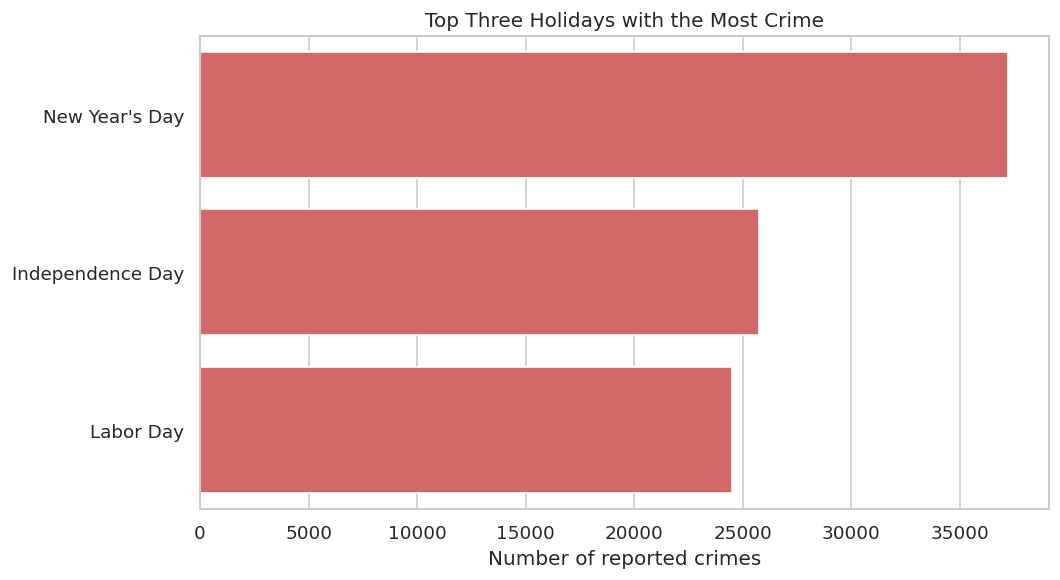

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=top3_holidays.values,
    y=top3_holidays.index,
    color='#E45756',
    ax=ax
)
ax.set(
    title='Top Three Holidays with the Most Crime',
    xlabel='Number of reported crimes',
    ylabel=''
)
fig.tight_layout()
plt.show()

In [53]:
## Top Five Crime Types on Each of the Top Three Holidays
top_holiday_names = top3_holidays.index.tolist()
top_holiday_crimes = (
    holiday_df.loc[holiday_df['US Holiday'].isin(top_holiday_names)]
    .groupby(['US Holiday', 'Primary Type'], observed=True)
    .size()
    .reset_index(name='Number of Crimes')
)
top5_by_holiday = (
    top_holiday_crimes
    .sort_values(['US Holiday', 'Number of Crimes'], ascending=[True, False])
    .groupby('US Holiday', sort=False)
    .head(5)
)

for holiday_name in top_holiday_names:
    print(f'\n{holiday_name}:')
    display(
        top5_by_holiday.loc[top5_by_holiday['US Holiday'] == holiday_name]
        [['Primary Type', 'Number of Crimes']]
        .reset_index(drop=True)
    )


New Year's Day:


,Primary Type,Number of Crimes
0,THEFT,7334
1,BATTERY,6883
2,CRIMINAL DAMAGE,3782
3,DECEPTIVE PRACTICE,3706
4,OTHER OFFENSE,2676



Independence Day:


,Primary Type,Number of Crimes
0,BATTERY,6495
1,THEFT,4618
2,CRIMINAL DAMAGE,3752
3,ASSAULT,1824
4,NARCOTICS,1590



Labor Day:


,Primary Type,Number of Crimes
0,BATTERY,5061
1,THEFT,4989
2,CRIMINAL DAMAGE,2768
3,NARCOTICS,2130
4,ASSAULT,1730


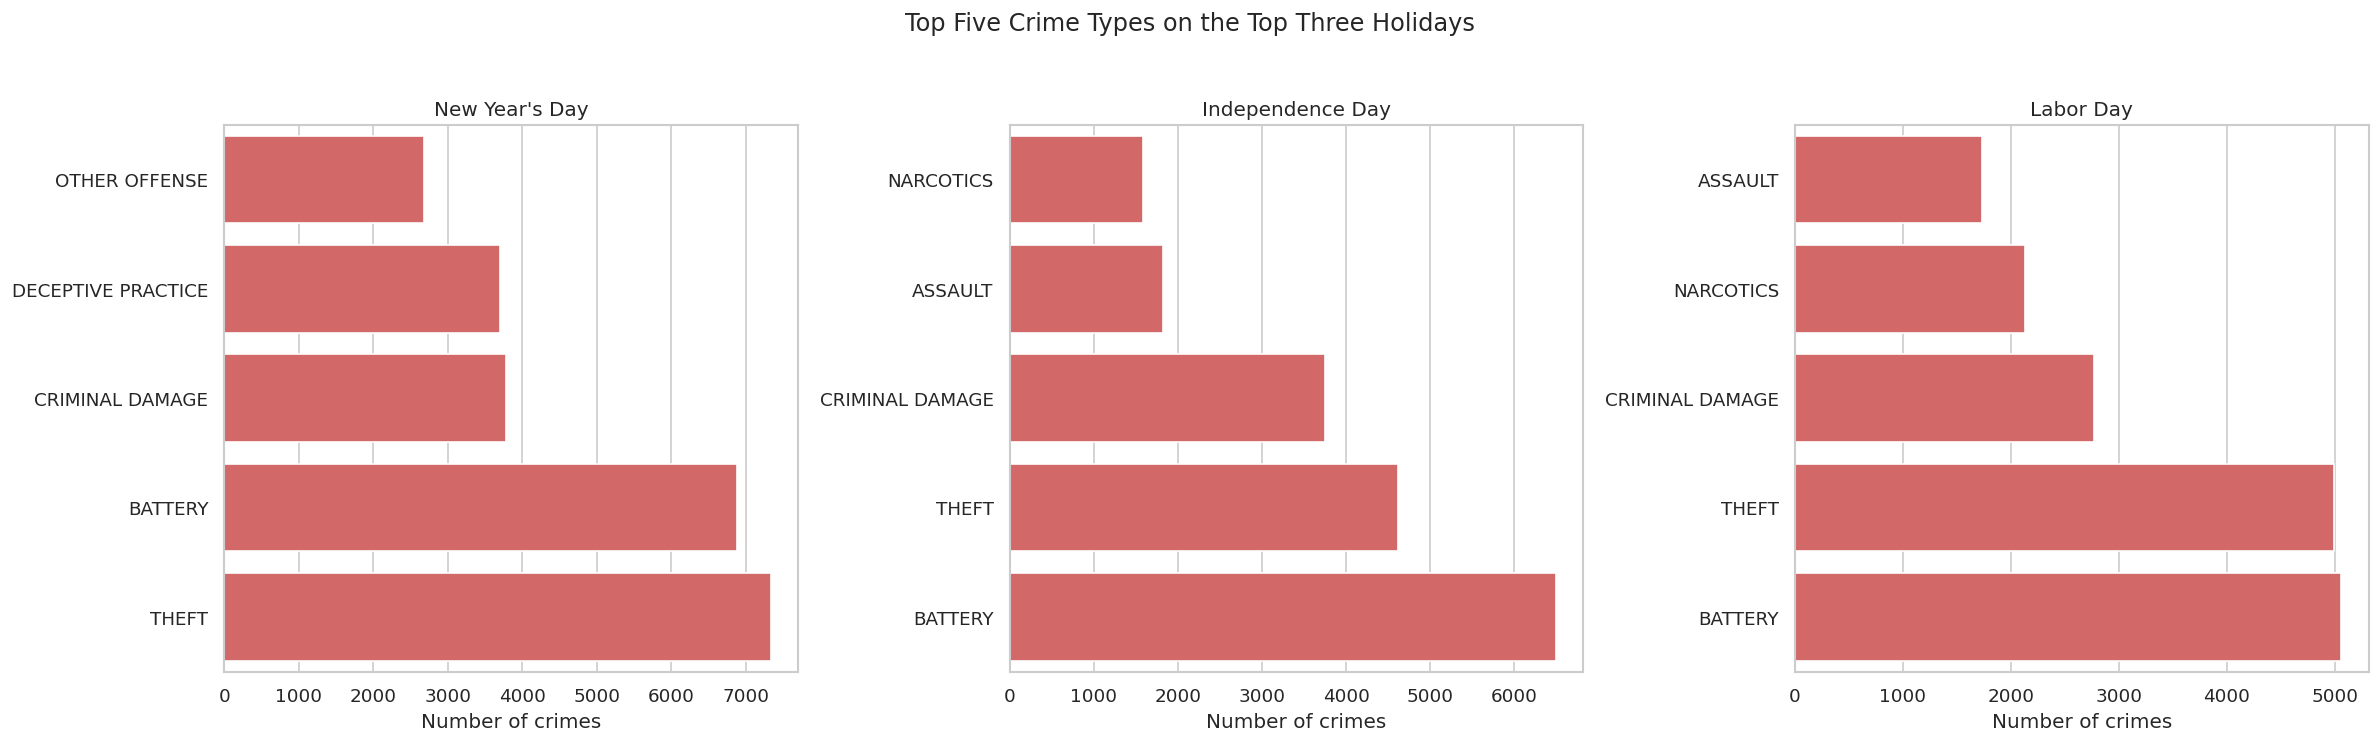

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, holiday_name in zip(axes, top_holiday_names):
    plot_df = (
        top5_by_holiday.loc[top5_by_holiday['US Holiday'] == holiday_name]
        .sort_values('Number of Crimes')
    )
    sns.barplot(
        data=plot_df,
        x='Number of Crimes',
        y='Primary Type',
        color='#E45756',
        ax=ax
    )
    ax.set_title(holiday_name)
    ax.set_xlabel('Number of crimes')
    ax.set_ylabel('')

fig.suptitle('Top Five Crime Types on the Top Three Holidays', y=1.03)
fig.tight_layout()
plt.show()

# Crime Seasonality

Two cycles are tested with `seasonal_decompose()`:

1. Daily crime with a period of **7 days** to test a weekly cycle.
2. Monthly crime with a period of **12 months** to test an annual cycle.

The magnitude is the maximum seasonal effect minus the minimum seasonal effect. It is measured in number of crimes.

In [ ]:
daily_counts = df.resample('D').size().asfreq('D', fill_value=0)
weekly_decomposition = seasonal_decompose(
    daily_counts,
    model='additive',
    period=7,
    extrapolate_trend='freq'
)

daily_counts.head()

## Weekly Cycle: Full Decomposition

In [ ]:
fig = weekly_decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Daily Crime Decomposition: 7-Day Cycle', y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]
weekly_pattern = (
    weekly_decomposition.seasonal
    .groupby(weekly_decomposition.seasonal.index.day_name())
    .mean()
    .reindex(weekday_order)
)
weekly_magnitude = weekly_pattern.max() - weekly_pattern.min()
weekly_peak_day = weekly_pattern.idxmax()
weekly_low_day = weekly_pattern.idxmin()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    x=weekly_pattern.index,
    y=weekly_pattern.values,
    marker='o',
    color='#54A24B',
    ax=ax
)
ax.set(
    title='Average Seasonal Effect Across One Weekly Cycle',
    xlabel='Day of week',
    ylabel='Seasonal effect (crimes)'
)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

print('Cycle length: 7 days')
print(f'Cycle magnitude: {weekly_magnitude:.1f} crimes')
print(f'Highest seasonal point: {weekly_peak_day}')
print(f'Lowest seasonal point: {weekly_low_day}')

In [ ]:
monthly_counts = df.resample('MS').size()
annual_decomposition = seasonal_decompose(
    monthly_counts,
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

monthly_counts.head()

## Annual Cycle: Full Decomposition

In [ ]:
fig = annual_decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Monthly Crime Decomposition: 12-Month Cycle', y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]
monthly_pattern = (
    annual_decomposition.seasonal
    .groupby(annual_decomposition.seasonal.index.month)
    .mean()
)
monthly_pattern.index = month_labels
annual_magnitude = monthly_pattern.max() - monthly_pattern.min()
annual_peak_month = monthly_pattern.idxmax()
annual_low_month = monthly_pattern.idxmin()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker='o',
    color='#B279A2',
    ax=ax
)
ax.set(
    title='Average Seasonal Effect Across One Annual Cycle',
    xlabel='Month',
    ylabel='Seasonal effect (crimes)'
)
fig.tight_layout()
plt.show()

print('Cycle length: 12 months')
print(f'Cycle magnitude: {annual_magnitude:.1f} crimes')
print(f'Highest seasonal point: {annual_peak_month}')
print(f'Lowest seasonal point: {annual_low_month}')